In [2]:
import sys
import os

# Add the project root (where the nn/ folder lives) to the import path
sys.path.insert(0, os.path.abspath('../..'))

# Now you can import from nn
from nn import network2
from nn import mnist_loader

Epoch 0 training complete
Cost on training data: 0.3297166361363805
Epoch 0 training complete
Cost on training data: 0.2626549525511968
Epoch 0 training complete
Cost on training data: 0.3250714335575769
Epoch 0 training complete
Cost on training data: 0.24706885824926464
Epoch 0 training complete
Cost on training data: 0.3202771250498675
Epoch 0 training complete
Cost on training data: 0.23305618094261463
Epoch 0 training complete
Cost on training data: 0.31533308998883125
Epoch 0 training complete
Cost on training data: 0.2204069627470424
Epoch 0 training complete
Cost on training data: 0.3102394586631111
Epoch 0 training complete
Cost on training data: 0.20894465382464425
Epoch 0 training complete
Cost on training data: 0.30499720648382234
Epoch 0 training complete
Cost on training data: 0.1985201415951003
Epoch 0 training complete
Cost on training data: 0.29960824804679126
Epoch 0 training complete
Cost on training data: 0.1890069263432832
Epoch 0 training complete
Cost on training

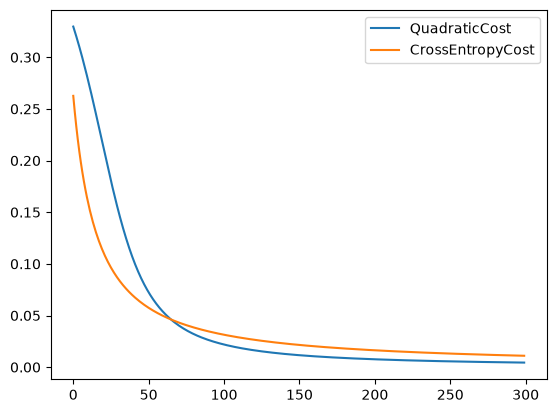

In [3]:
# PART 1 - recreate the cost graphs

import numpy as np

net1 = network2.Network([1, 1], cost=network2.QuadraticCost)
net2 = network2.Network([1, 1], cost=network2.CrossEntropyCost)

training_data = [(np.array([[1.0]]), np.array([[0.0]]))]
net1.weights= [np.array([[0.6]])]
net1.biases = [np.array([[0.9]])]

costs1 = []
costs2 = []
for _ in range(300):
    (_, _, train_cost, _) = net1.SGD(training_data, 1, 1, 0.15, 0.0, monitor_training_cost=True)
    costs1.append(train_cost[0])
    (_, _, train_cost, _) = net2.SGD(training_data, 1, 1, 0.15, 0.0, monitor_training_cost=True)
    costs2.append(train_cost[0])

import matplotlib.pyplot as plt

plt.plot(costs1, label='QuadraticCost')
plt.plot(costs2, label='CrossEntropyCost')
plt.legend()
plt.show()



Epoch 0 training complete
Cost on training data: 2.2225823302096415
Accuracy on training data: 544 / 1000
Cost on evaluation data: 2.4280599161774283
Accuracy on evaluation data: 4926 / 10000
Epoch 1 training complete
Cost on training data: 1.4454776694182712
Accuracy on training data: 767 / 1000
Cost on evaluation data: 1.7946037921821087
Accuracy on evaluation data: 6713 / 10000
Epoch 2 training complete
Cost on training data: 1.1521646675707946
Accuracy on training data: 816 / 1000
Cost on evaluation data: 1.5680203596114861
Accuracy on evaluation data: 7209 / 10000
Epoch 3 training complete
Cost on training data: 0.9579601785867204
Accuracy on training data: 872 / 1000
Cost on evaluation data: 1.4349815797684051
Accuracy on evaluation data: 7534 / 10000
Epoch 4 training complete
Cost on training data: 0.8326448719581762
Accuracy on training data: 887 / 1000
Cost on evaluation data: 1.373372743345001
Accuracy on evaluation data: 7719 / 10000
Epoch 5 training complete
Cost on trainin

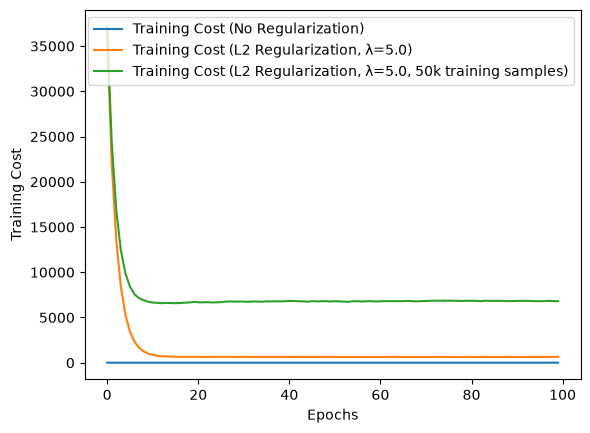

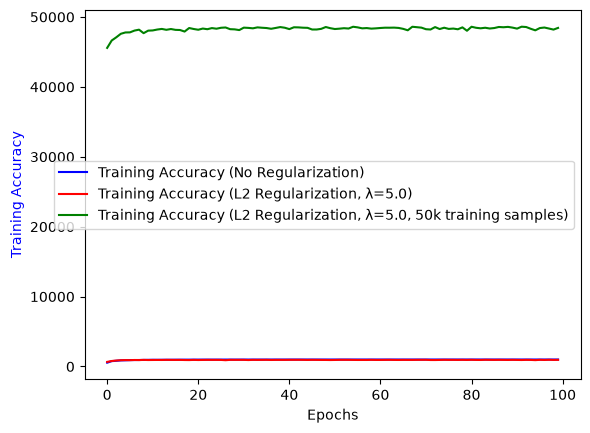

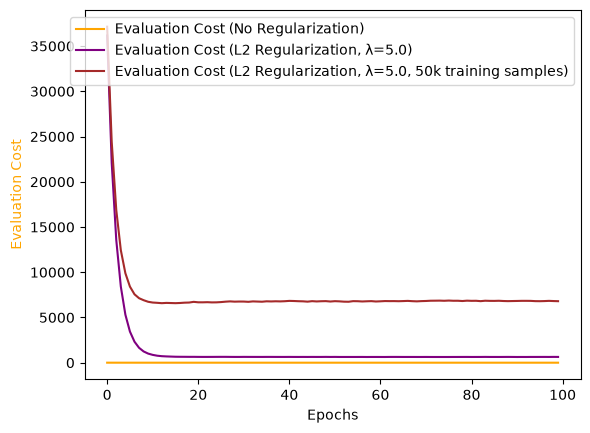

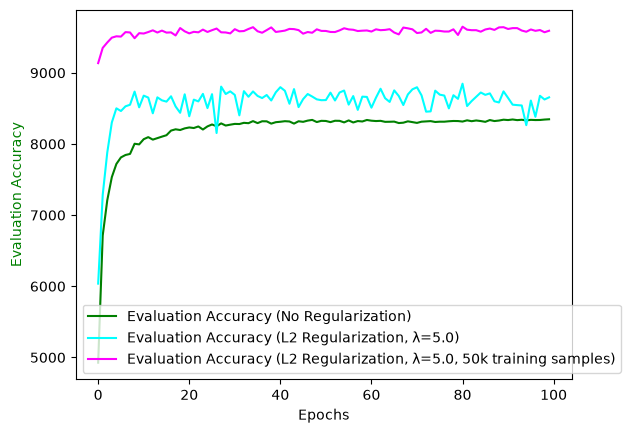

In [14]:
# PART 2 - Overfitting and regularization
netA = network2.Network(
    [784, 30, 10],
    cost=network2.CrossEntropyCost
)

netB = network2.Network(
    [784, 30, 10],
    cost=network2.CrossEntropyCost
)

netC = network2.Network(
    [784, 30, 10],
    cost=network2.CrossEntropyCost
)

netA.large_weight_initializer()
netB.large_weight_initializer()
netC.large_weight_initializer()

training_data, validation_data, test_data = mnist_loader.load_data_wrapper('../../nn/mnist.pkl.gz')
training_data = list(training_data)
validation_data = list(validation_data)
test_data = list(test_data)

tcostA, taccA, ecostA, eaccA = netA.SGD(
    training_data[:1000],
    epochs=100,
    mini_batch_size=10,
    eta=0.5,
    evaluation_data=validation_data,
    lmbda=0,
    monitor_training_cost=True,
    monitor_training_accuracy=True,
    monitor_evaluation_cost=True,
    monitor_evaluation_accuracy=True
)

tcostB, taccB, ecostB, eaccB = netB.SGD(
    training_data[:1000],
    epochs=100,
    mini_batch_size=10,
    eta=0.5,
    evaluation_data=validation_data,
    lmbda=5.0,
    monitor_training_cost=True,
    monitor_training_accuracy=True,
    monitor_evaluation_cost=True,
    monitor_evaluation_accuracy=True
)

tcostC, taccC, ecostC, eaccC = netC.SGD(
    training_data[:50000],
    epochs=100,
    mini_batch_size=10,
    eta=0.5,
    evaluation_data=validation_data,
    lmbda=5.0,
    monitor_training_cost=True,
    monitor_training_accuracy=True,
    monitor_evaluation_cost=True,
    monitor_evaluation_accuracy=True
)

#plot the results
import matplotlib.pyplot as plt

#training costs
plt.plot(tcostA, label='Training Cost (No Regularization)')
plt.plot(tcostB, label='Training Cost (L2 Regularization, λ=5.0)')
plt.plot(tcostC, label='Training Cost (L2 Regularization, λ=5.0, 50k training samples)')
plt.xlabel('Epochs')
plt.ylabel('Training Cost')
plt.legend()

#training accuracy
fig, ax1 = plt.subplots()
ax1.plot(eaccA, label='Training Accuracy (No Regularization)', color='blue')
ax1.plot(eaccB, label='Training Accuracy (L2 Regularization, λ=5.0)', color='red')
ax1.plot(eaccC, label='Training Accuracy (L2 Regularization, λ=5.0, 50k training samples)', color='green')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Training Accuracy', color='blue')
plt.legend()

#evaluation cost
fig, ax2 = plt.subplots()
ax2.plot(ecostA, label='Evaluation Cost (No Regularization)', color='orange')
ax2.plot(ecostB, label='Evaluation Cost (L2 Regularization, λ=5.0)', color='purple')
ax2.plot(ecostC, label='Evaluation Cost (L2 Regularization, λ=5.0, 50k training samples)', color='brown')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Evaluation Cost', color='orange')
plt.legend()

#evaluation accuracy
fig, ax3 = plt.subplots()
ax3.plot(taccA, label='Evaluation Accuracy (No Regularization)', color='green')
ax3.plot(taccB, label='Evaluation Accuracy (L2 Regularization, λ=5.0)', color='cyan')
ax3.plot(taccC, label='Evaluation Accuracy (L2 Regularization, λ=5.0, 50k training samples)', color='magenta')
ax3.set_xlabel('Epochs')
ax3.set_ylabel('Evaluation Accuracy', color='green')
plt.legend()

